# HumanLens AI — Dataset Analysis

## Primary Dataset: Civil Comments / Jigsaw Unintended Bias

This notebook performs the initial verification and exploratory analysis
of the primary HumanLens text dataset.

### Objectives

1. Load the official Civil Comments dataset.
2. Verify dataset structure and splits.
3. Inspect available features and labels.
4. Check missing values and duplicates.
5. Analyze toxicity-related label distributions.
6. Examine class imbalance.
7. Inspect text length and quality.
8. Create a controlled development dataset for experiments.
9. Preserve the official validation and test splits for final evaluation.

### HumanLens Text Layer

The dataset will primarily support:

- Toxicity detection
- Aggression-related modeling
- Insult detection
- Threat detection
- Additional harmful-language analysis

The dataset will not be treated as a direct representation of
real-time interpersonal communication. Results will be interpreted
within the limitations of the source data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
import datasets

print("datasets version:", datasets.__version__)
print("datasets imported successfully.")

datasets version: 5.0.1
datasets imported successfully.


In [3]:
dataset = load_dataset("google/civil_comments")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'toxicity', 'severe_toxicity', 'obscene', 'threat', 'insult', 'identity_attack', 'sexual_explicit'],
        num_rows: 1804874
    })
    validation: Dataset({
        features: ['text', 'toxicity', 'severe_toxicity', 'obscene', 'threat', 'insult', 'identity_attack', 'sexual_explicit'],
        num_rows: 97320
    })
    test: Dataset({
        features: ['text', 'toxicity', 'severe_toxicity', 'obscene', 'threat', 'insult', 'identity_attack', 'sexual_explicit'],
        num_rows: 97320
    })
})


In [4]:
print("Dataset sizes:")
print("-" * 40)

for split in dataset:
    print(f"{split:12} : {len(dataset[split]):,} rows")

Dataset sizes:
----------------------------------------
train        : 1,804,874 rows
validation   : 97,320 rows
test         : 97,320 rows


In [5]:
print("Dataset columns:")
print("-" * 40)

for column in dataset["train"].column_names:
    print("-", column)

Dataset columns:
----------------------------------------
- text
- toxicity
- severe_toxicity
- obscene
- threat
- insult
- identity_attack
- sexual_explicit


In [6]:
sample_preview = dataset["train"].select(range(10)).to_pandas()

sample_preview

,text,toxicity,severe_toxicity,obscene,threat,insult,identity_attack,sexual_explicit
0,"This is so cool. It's like, 'would you want yo...",0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
1,Thank you!! This would make my life a lot less...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
2,This is such an urgent design problem; kudos t...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
3,Is this something I'll be able to install on m...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
4,haha you guys are a bunch of losers.,0.893617,0.021277,0.000000,0.0,0.872340,0.021277,0.000000
5,ur a sh*tty comment.,0.666667,0.047619,0.638095,0.0,0.333333,0.000000,0.009524
6,hahahahahahahahhha suck it.,0.457627,0.050847,0.305085,0.0,0.254237,0.000000,0.220339
7,FFFFUUUUUUUUUUUUUUU,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
8,The ranchers seem motivated by mostly by greed...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
9,It was a great show. Not a combo I'd of expect...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000


## Multilingual Research Requirement

HumanLens is intended to support multilingual communication rather than
English-only text.

The primary target languages and varieties are:

- English
- Hindi
- Hinglish / Hindi-English code-mixed text
- Major Indian languages where suitable datasets are available
- Additional world languages where sufficient training and evaluation
  data are available

The system should not assume that English toxicity models will transfer
reliably to other languages.

Therefore, multilingual evaluation will be treated as a separate
research requirement.

### Initial Research Strategy

1. Use Civil Comments as the English toxicity foundation.
2. Add multilingual toxicity data for broader language coverage.
3. Include dedicated Hindi data.
4. Include Hinglish/code-mixed data.
5. Add Indian-language datasets where data quality and licensing permit.
6. Evaluate performance separately by language.
7. Measure whether multilingual training improves or reduces performance
   for individual languages.

### Important Limitation

HumanLens will not claim perfect understanding of every language in the
world.

Instead, language coverage will be reported using measured evaluation
results for each supported language.

Unknown or unsupported languages should produce a lower-confidence result
rather than being treated as reliably understood.

In [7]:
print(dataset["train"].features)

{'text': Value('string'), 'toxicity': Value('float32'), 'severe_toxicity': Value('float32'), 'obscene': Value('float32'), 'threat': Value('float32'), 'insult': Value('float32'), 'identity_attack': Value('float32'), 'sexual_explicit': Value('float32')}


In [8]:
DEV_SIZE = 100_000
RANDOM_SEED = 42

train_dev = dataset["train"].shuffle(
    seed=RANDOM_SEED
).select(range(DEV_SIZE))

print(f"Development dataset size: {len(train_dev):,}")

Development dataset size: 100,000


In [9]:
train_df = train_dev.to_pandas()

print("Shape:", train_df.shape)
train_df.head()

Shape: (100000, 8)


,text,toxicity,severe_toxicity,obscene,threat,insult,identity_attack,sexual_explicit
0,Socialists? What the hell does that have to do...,0.300000,0.000000,0.300000,0.0,0.200000,0.0,0.0
1,And I always thought that Eric Trump was the d...,0.808824,0.029412,0.088235,0.0,0.794118,0.0,0.0
2,I’m disappointed there’s no report from CB on ...,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0
3,Nothing like subsidizing a country that is thr...,0.166667,0.000000,0.000000,0.0,0.166667,0.0,0.0
4,The only way to save the rhino is to legalize ...,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0


In [10]:
print("Missing values:")
print(train_df.isnull().sum())

Missing values:
text               0
toxicity           0
severe_toxicity    0
obscene            0
threat             0
insult             0
identity_attack    0
sexual_explicit    0
dtype: int64


In [12]:
print("\nTotal missing values:",
      train_df.isnull().sum().sum())


Total missing values: 0


In [13]:
duplicate_count = train_df["text"].duplicated().sum()

print("Duplicate text entries:", duplicate_count)

Duplicate text entries: 281


In [14]:
empty_comments = train_df["text"].fillna("").str.strip().eq("").sum()

print("Empty or blank comments:", empty_comments)

Empty or blank comments: 0


In [15]:
label_columns = [
    "toxicity",
    "severe_toxicity",
    "obscene",
    "threat",
    "insult",
    "identity_attack",
    "sexual_explicit"
]

label_stats = train_df[label_columns].describe().T

label_stats

,count,mean,std,min,25%,50%,75%,max
toxicity,100000.0,0.102230,0.195628,0.0,0.0,0.0,0.166667,1.0
severe_toxicity,100000.0,0.004562,0.022724,0.0,0.0,0.0,0.000000,0.5
obscene,100000.0,0.013995,0.065236,0.0,0.0,0.0,0.000000,1.0
threat,100000.0,0.009248,0.048606,0.0,0.0,0.0,0.000000,1.0
insult,100000.0,0.080367,0.174344,0.0,0.0,0.0,0.045455,1.0
identity_attack,100000.0,0.022283,0.077367,0.0,0.0,0.0,0.000000,1.0
sexual_explicit,100000.0,0.006592,0.045158,0.0,0.0,0.0,0.000000,1.0


In [16]:
from pathlib import Path

output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "civil_comments_train_dev_100k.csv"

train_df.to_csv(output_path, index=False)

print(f"Saved successfully to: {output_path}")

Saved successfully to: ..\data\processed\civil_comments_train_dev_100k.csv


In [17]:
label_columns = [
    "toxicity",
    "severe_toxicity",
    "obscene",
    "threat",
    "insult",
    "identity_attack",
    "sexual_explicit"
]

for label in label_columns:
    print(f"\n{label.upper()}")
    print("-" * 40)
    print(train_df[label].describe())


TOXICITY
----------------------------------------
count    100000.000000
mean          0.102230
std           0.195628
min           0.000000
25%           0.000000
50%           0.000000
75%           0.166667
max           1.000000
Name: toxicity, dtype: float64

SEVERE_TOXICITY
----------------------------------------
count    100000.000000
mean          0.004562
std           0.022724
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           0.500000
Name: severe_toxicity, dtype: float64

OBSCENE
----------------------------------------
count    100000.000000
mean          0.013995
std           0.065236
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: obscene, dtype: float64

THREAT
----------------------------------------
count    100000.000000
mean          0.009248
std           0.048606
min           0.000000
25%           0.000000
50%           0.000000
75%

In [18]:
toxicity_thresholds = [0.25, 0.50, 0.75, 0.85, 0.90]

print("TOXICITY THRESHOLD ANALYSIS")
print("=" * 50)

for threshold in toxicity_thresholds:
    count = (train_df["toxicity"] >= threshold).sum()
    percentage = (count / len(train_df)) * 100

    print(
        f"Toxicity >= {threshold:.2f}: "
        f"{count:,} comments "
        f"({percentage:.2f}%)"
    )

TOXICITY THRESHOLD ANALYSIS
Toxicity >= 0.25: 14,848 comments (14.85%)
Toxicity >= 0.50: 7,836 comments (7.84%)
Toxicity >= 0.75: 2,076 comments (2.08%)
Toxicity >= 0.85: 751 comments (0.75%)
Toxicity >= 0.90: 473 comments (0.47%)


In [19]:
TOXICITY_THRESHOLD = 0.50

train_df["is_toxic"] = (
    train_df["toxicity"] >= TOXICITY_THRESHOLD
).astype(int)

print(train_df["is_toxic"].value_counts())

is_toxic
0    92164
1     7836
Name: count, dtype: int64


In [20]:
print(
    train_df["is_toxic"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

is_toxic
0    92.16
1     7.84
Name: proportion, dtype: float64


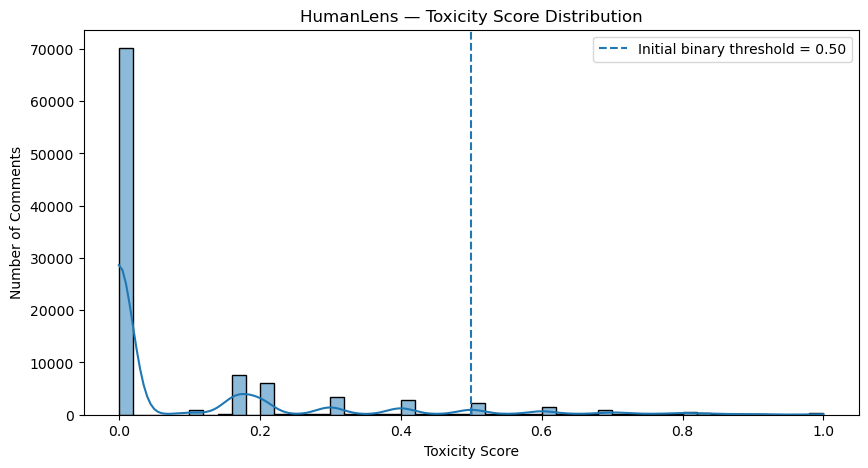

In [21]:
plt.figure(figsize=(10, 5))

sns.histplot(
    train_df["toxicity"],
    bins=50,
    kde=True
)

plt.axvline(
    0.50,
    linestyle="--",
    label="Initial binary threshold = 0.50"
)

plt.title("HumanLens — Toxicity Score Distribution")
plt.xlabel("Toxicity Score")
plt.ylabel("Number of Comments")
plt.legend()

plt.show()

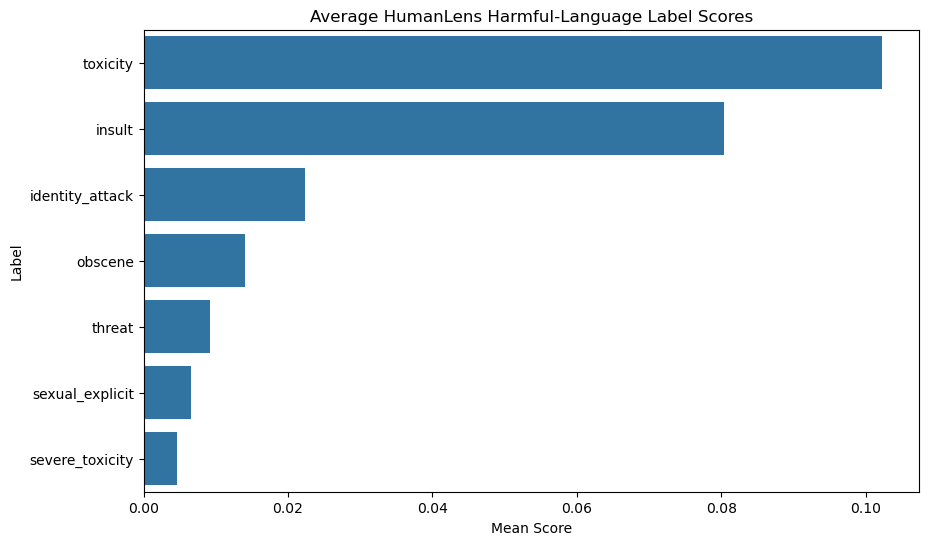

In [22]:
mean_scores = (
    train_df[label_columns]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=mean_scores.values,
    y=mean_scores.index
)

plt.title("Average HumanLens Harmful-Language Label Scores")
plt.xlabel("Mean Score")
plt.ylabel("Label")

plt.show()

In [23]:
from pathlib import Path

output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "civil_comments_train_dev_100k.csv"

train_df.to_csv(
    output_path,
    index=False
)

print(f"Saved successfully to: {output_path}")

Saved successfully to: ..\data\processed\civil_comments_train_dev_100k.csv


# Initial Dataset Analysis — Findings

## Dataset

The Civil Comments dataset provides the primary English-language
toxicity data for the initial HumanLens text-layer experiments.

## Development Dataset

A reproducible 100,000-comment development subset was created using
random seed 42.

## Labels

The dataset contains continuous scores for:

- Toxicity
- Severe toxicity
- Obscene
- Threat
- Insult
- Identity attack
- Sexual explicit

## Initial Toxicity Classification

An initial toxicity threshold of 0.50 is used only for baseline
experimentation.

This threshold is not considered the final HumanLens intervention
threshold.

Final escalation thresholds will be determined using validation
experiments involving precision, recall, F1-score, calibration and
false-positive analysis.

## Multilingual Limitation

Civil Comments primarily supports the English-language component of
the initial research.

Additional multilingual, Hindi, Hinglish and Indian-language datasets
will therefore be required before claiming multilingual HumanLens
capability.

## Next Step

The next stage is detailed text exploratory data analysis and
preprocessing, followed by multilingual dataset integration.